# MATH-500 EDA

phase01 difficulty verification — 다운로드한 MATH-500 test split 탐색.

- 데이터: `data/math500_test.jsonl` (500 examples)
- 컬럼: `problem`, `solution`, `answer`, `subject`, `level`, `unique_id`
- GSM8K/MMLU와 달리 **난이도 레벨(level 1~5)** 과 **과목(subject)** 라벨이 내장 → 난이도 분석에 유용

> 노트북은 phase01 루트(`phase01_difficulty_verification/`) 기준으로 실행한다 (경로 `data/...`).

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 200)
DATA_PATH = "../data/math500_test.jsonl"

## 1. 로드 및 기본 정보

In [2]:
records = [json.loads(line) for line in open(DATA_PATH, encoding="utf-8")]
df = pd.DataFrame(records)

print("num examples:", len(df))
print("columns     :", list(df.columns))
print("nulls       :\n", df.isna().sum())
print("duplicated problems:", df["problem"].duplicated().sum())
df.head(3)

num examples: 500
columns     : ['problem', 'solution', 'answer', 'subject', 'level', 'unique_id']
nulls       :
 problem      0
solution     0
answer       0
subject      0
level        0
unique_id    0
dtype: int64
duplicated problems: 0


,problem,solution,answer,subject,level,unique_id
0,"Convert the point $(0,3)$ in rectangular coordinates to polar coordinates. Enter your answer in the form $(r,\theta),$ where $r > 0$ and $0 \le \theta < 2 \pi.$","We have that $r = \sqrt{0^2 + 3^2} = 3.$ Also, if we draw the line connecting the origin and $(0,3),$ this line makes an angle of $\frac{\pi}{2}$ with the positive $x$-axis.\n\n[asy]\nunitsize(0....","\left( 3, \frac{\pi}{2} \right)",Precalculus,2,test/precalculus/807.json
1,Define\n\[p = \sum_{k = 1}^\infty \frac{1}{k^2} \quad \text{and} \quad q = \sum_{k = 1}^\infty \frac{1}{k^3}.\]Find a way to write\n\[\sum_{j = 1}^\infty \sum_{k = 1}^\infty \frac{1}{(j + k)^3}\]i...,"We count the number of times $\frac{1}{n^3}$ appears in the sum\n\[\sum_{j = 1}^\infty \sum_{k = 1}^\infty \frac{1}{(j + k)^3},\]where $n$ is a fixed positive integer. (In other words, we are con...",p - q,Intermediate Algebra,5,test/intermediate_algebra/1994.json
2,"If $f(x) = \frac{3x-2}{x-2}$, what is the value of $f(-2) +f(-1)+f(0)$? Express your answer as a common fraction.",$f(-2)+f(-1)+f(0)=\frac{3(-2)-2}{-2-2}+\frac{3(-1)-2}{-1-2}+\frac{3(0)-2}{0-2}=\frac{-8}{-4}+\frac{-5}{-3}+\frac{-2}{-2}=2+\frac{5}{3}+1=\boxed{\frac{14}{3}}$,\frac{14}{3},Algebra,3,test/algebra/2584.json


## 2. 파생 피처 추출

- `prob_char_len` / `prob_word_len`: 문제 길이
- `sol_char_len`: 풀이(solution) 길이
- `ans_char_len`: 정답 문자열 길이
- `has_boxed`: 풀이에 `\boxed{...}`(최종 정답 표기) 포함 여부

In [3]:
df["prob_char_len"] = df["problem"].str.len()
df["prob_word_len"] = df["problem"].str.split().apply(len)
df["sol_char_len"]  = df["solution"].str.len()
df["ans_char_len"]  = df["answer"].astype(str).str.len()
df["has_boxed"]     = df["solution"].str.contains(r"\\boxed", regex=True)

print("\\boxed 포함 비율: {:.1f}%".format(df["has_boxed"].mean() * 100))
df[["level", "prob_char_len", "prob_word_len", "sol_char_len", "ans_char_len"]].describe().round(1)

\boxed 포함 비율: 100.0%


,level,prob_char_len,prob_word_len,sol_char_len,ans_char_len
count,500.0,500.0,500.0,500.0,500.0
mean,3.4,195.9,31.5,531.3,5.9
std,1.3,179.2,23.5,404.4,7.7
min,1.0,20.0,2.0,45.0,1.0
25%,2.0,92.8,16.0,245.0,2.0
50%,4.0,148.0,26.0,421.5,3.0
75%,5.0,235.2,42.0,683.2,8.0
max,5.0,1733.0,206.0,3356.0,53.0


## 3. 난이도 레벨(level) 분포

MATH-500의 핵심 난이도 신호. level 1(쉬움) ~ 5(어려움).

level
1     43
2     90
3    105
4    128
5    134
Name: count, dtype: int64


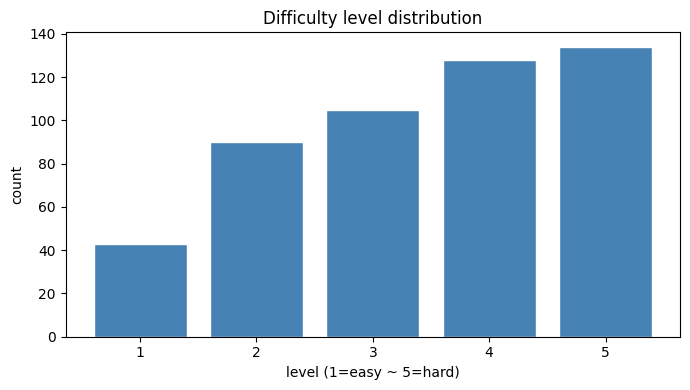

In [4]:
level_counts = df["level"].value_counts().sort_index()
print(level_counts)

plt.figure(figsize=(7, 4))
plt.bar(level_counts.index.astype(str), level_counts.values, color="steelblue", edgecolor="white")
plt.title("Difficulty level distribution")
plt.xlabel("level (1=easy ~ 5=hard)"); plt.ylabel("count")
plt.tight_layout(); plt.show()

## 4. 과목(subject) 분포

subject
Algebra                   124
Intermediate Algebra       97
Prealgebra                 82
Number Theory              62
Precalculus                56
Geometry                   41
Counting & Probability     38
Name: count, dtype: int64


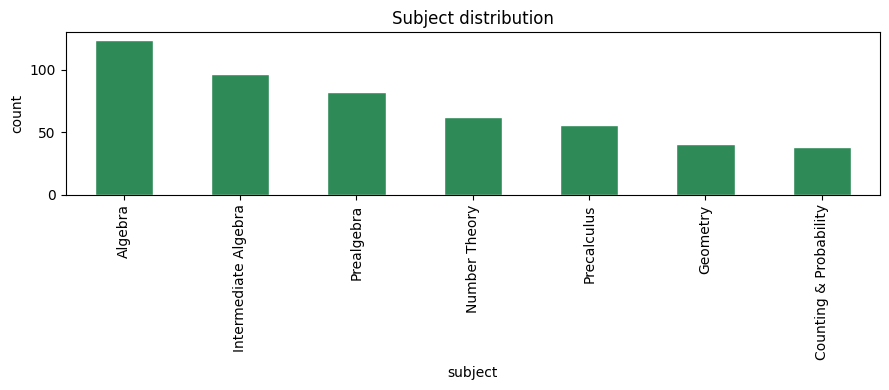

In [5]:
subj_counts = df["subject"].value_counts()
print(subj_counts)

plt.figure(figsize=(9, 4))
subj_counts.plot(kind="bar", color="seagreen", edgecolor="white")
plt.title("Subject distribution")
plt.ylabel("count"); plt.xlabel("subject")
plt.tight_layout(); plt.show()

## 5. 과목 × 레벨 교차표

어떤 과목이 어려운 레벨에 몰려 있는지 확인.

level,1,2,3,4,5
subject,,,,,
Algebra,17,21,26,30,30
Counting & Probability,2,7,4,13,12
Geometry,2,8,8,10,13
Intermediate Algebra,7,12,19,23,36
Number Theory,5,10,16,19,12
Prealgebra,7,19,17,20,19
Precalculus,3,13,15,13,12


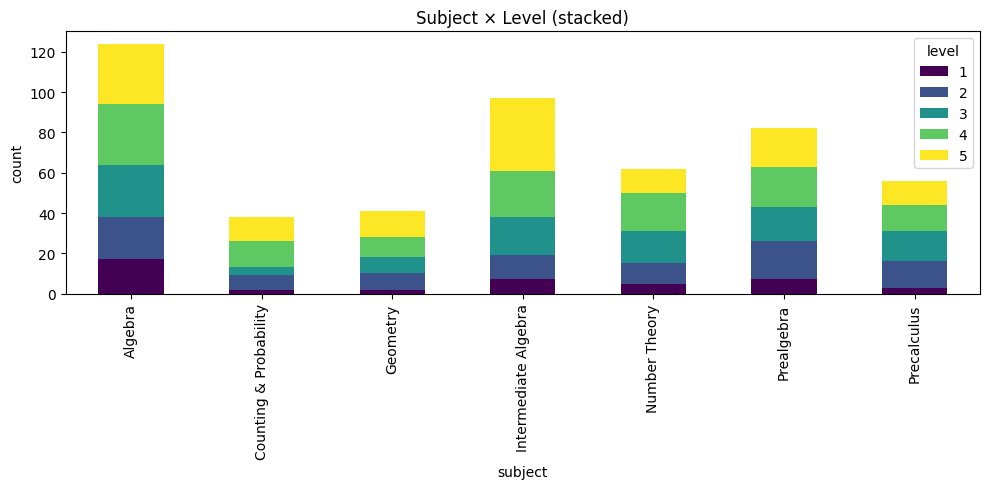

In [6]:
ct = pd.crosstab(df["subject"], df["level"])
display(ct)

ct.plot(kind="bar", stacked=True, figsize=(10, 5), colormap="viridis")
plt.title("Subject × Level (stacked)")
plt.ylabel("count"); plt.xlabel("subject"); plt.legend(title="level")
plt.tight_layout(); plt.show()

## 6. 길이 ↔ 난이도(level) 관계

레벨이 올라갈수록 문제/풀이가 길어지는가? (길이가 난이도의 proxy가 되는지 확인)

       prob_char_len  prob_word_len  sol_char_len
level                                            
1              122.2           21.3         243.3
2              147.8           23.8         364.1
3              165.0           26.9         459.4
4              206.1           32.7         506.5
5              266.3           42.4         816.0


/tmp/ipykernel_1219467/1097522787.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(data, labels=sorted(df["level"].unique()), showmeans=True)


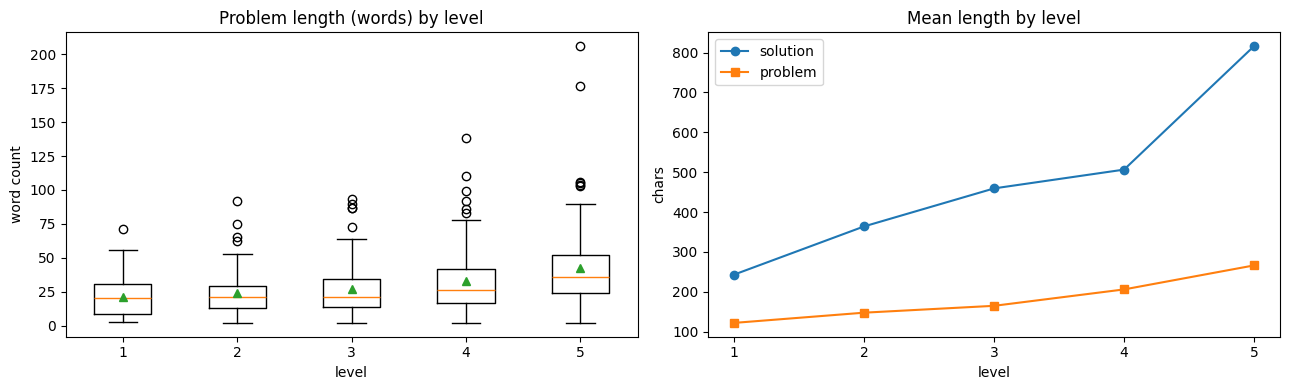


correlation(level, prob_word_len): 0.309
correlation(level, sol_char_len) : 0.434


In [7]:
by_level = df.groupby("level")[["prob_char_len", "prob_word_len", "sol_char_len"]].mean().round(1)
print(by_level)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
# 레벨별 문제 길이 박스플롯
data = [df[df["level"] == lv]["prob_word_len"] for lv in sorted(df["level"].unique())]
axes[0].boxplot(data, labels=sorted(df["level"].unique()), showmeans=True)
axes[0].set_title("Problem length (words) by level")
axes[0].set_xlabel("level"); axes[0].set_ylabel("word count")

# 레벨별 풀이 길이 추세
axes[1].plot(by_level.index, by_level["sol_char_len"], marker="o", label="solution")
axes[1].plot(by_level.index, by_level["prob_char_len"], marker="s", label="problem")
axes[1].set_title("Mean length by level"); axes[1].set_xlabel("level")
axes[1].set_ylabel("chars"); axes[1].set_xticks(sorted(df["level"].unique())); axes[1].legend()
plt.tight_layout(); plt.show()

# 상관계수
print("\ncorrelation(level, prob_word_len):", round(df["level"].corr(df["prob_word_len"]), 3))
print("correlation(level, sol_char_len) :", round(df["level"].corr(df["sol_char_len"]), 3))

## 7. 레벨별 샘플 보기

In [8]:
def show(row):
    print("=" * 90)
    print(f"[level={row.level} | subject={row.subject}]")
    print("Problem :", row.problem[:300])
    print("Answer  :", row.answer)

for lv in sorted(df["level"].unique()):
    sub = df[df["level"] == lv]
    show(sub.iloc[0])
    print()

[level=1 | subject=Precalculus]
Problem : Suppose $\sin D = 0.7$ in the diagram below. What is $DE$? [asy]
pair D,E,F;
F = (0,0);
D = (sqrt(51),7);
E = (0,7);
draw(D--E--F--D);
draw(rightanglemark(D,E,F,15));
label("$D$",D,NE);
label("$E$",E,NW);
label("$F$",F,SW);
label("$7$",(E+F)/2,W);
[/asy]
Answer  : \sqrt{51}

[level=2 | subject=Precalculus]
Problem : Convert the point $(0,3)$ in rectangular coordinates to polar coordinates.  Enter your answer in the form $(r,\theta),$ where $r > 0$ and $0 \le \theta < 2 \pi.$
Answer  : \left( 3, \frac{\pi}{2} \right)

[level=3 | subject=Algebra]
Problem : If $f(x) = \frac{3x-2}{x-2}$, what is the value of $f(-2) +f(-1)+f(0)$? Express your answer as a common fraction.
Answer  : \frac{14}{3}

[level=4 | subject=Precalculus]
Problem : The set of points $(x,y,z)$ that satisfy
\[2x = 3y = -z\]is a line.

The set of points $(x,y,z)$ that satisfy
\[6x = -y = -4z\]is another line.

Find the angle between these lines, in degrees.
Answer  : 90^\circ

[lev

## 8. 요약 저장 (선택)

In [9]:
out_cols = ["unique_id", "subject", "level", "prob_char_len", "prob_word_len", "sol_char_len", "ans_char_len"]
df[out_cols].to_csv("data/math500_eda_features.csv", index=False)
print("saved -> data/math500_eda_features.csv")

OSError: Cannot save file into a non-existent directory: 'data'